# Explore a saved Archipelago Shapley analysis

Run `run_local.py` first. This notebook loads its saved result without regenerating worlds or rerunning Shapley permutations. Only load pickle files you trust.

In [1]:
from pathlib import Path
import sys

%matplotlib inline

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'ap_shapley').is_dir():
    raise RuntimeError('Open this notebook with the project directory as the working directory.')

ARCHIPELAGO_ROOT = PROJECT_ROOT / 'Archipelago'
if str(ARCHIPELAGO_ROOT) not in sys.path:
    sys.path.insert(0, str(ARCHIPELAGO_ROOT))

from ap_shapley.result import AnalysisResult

# This is created by the README quick-start command. Change it for your own result.
ANALYSIS_PATH = PROJECT_ROOT / 'output' / 'pokemon_rb_default_analysis.pkl.gz'
analysis = AnalysisResult.load(ANALYSIS_PATH)
ANALYSIS_PATH.resolve()

c:\Users\matth\Desktop\ap_shapley_project\Archipelago\NetUtils.py:532: UserWarning: _speedups not available. Falling back to pure python LocationStore. Install a matching C++ compiler for your platform to compile _speedups.
  warnings.warn("_speedups not available. Falling back to pure python LocationStore. "
c:\Users\matth\Desktop\ap_shapley_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


WindowsPath('C:/Users/matth/Desktop/ap_shapley_project/output/pokemon_rb_default_analysis.pkl.gz')

In [2]:
analysis.print_summary()
analysis.display_items(max_height=480)  # full table, ranked by shapley_per_copy

=== Archipelago Shapley analysis ===
game                               Pokemon Red and Blue
world_samples                      100
shapley_pairs_per_world            64
total_permutations                 12800
seed                               2026
release_on_goal                    True
scored_checks_min                  161
scored_checks_max                  161
free_checks_min                    3
free_checks_max                    3
item_dependent_checks_min          158
item_dependent_checks_max          158
shapley_item_copies_min            80
shapley_item_copies_max            80
distinct_item_families_min         78
distinct_item_families_max         78
precollected_item_count_min        0
precollected_item_count_max        0
constrained_item_copies_min        18
constrained_item_copies_max        22
constrained_item_families_min      18
constrained_item_families_max      22
pending_constrained_with_all_offered_max 0
reachable_with_all_items_min       161
reachable_with_all_

item,worlds_present,mean_copies,shapley_per_copy,observed_world_sd,family_total,sampling_se_mean,estimated_world_sd,total_se,ci95
Oak's Parcel,100,1.0,69.084063,3.113268,69.084063,0.176877,2.562010,0.311327,0.610201
Poke Flute,100,1.0,30.226328,7.414720,30.226328,0.163898,7.231307,0.741472,1.453285
Silph Scope,100,1.0,8.435937,2.598586,8.435937,0.107224,2.367055,0.259859,0.509323
HM03 Surf,100,1.0,7.538828,3.107636,7.538828,0.116157,2.882387,0.310764,0.609097
Soul Badge,100,1.0,7.506328,3.298864,7.506328,0.117533,3.082384,0.329886,0.646577
HM01 Cut,100,1.0,5.897734,3.118921,5.897734,0.097431,2.962833,0.311892,0.611309
Cascade Badge,100,1.0,5.740625,2.893982,5.740625,0.097480,2.724867,0.289398,0.567220
Card Key,100,1.0,5.730078,2.609586,5.730078,0.093579,2.436027,0.260959,0.511479
S.S. Ticket,100,1.0,3.087578,0.141766,3.087578,0.014263,0.000000,0.014177,0.027786
Secret Key,100,1.0,1.949844,1.159055,1.949844,0.052078,1.035470,0.115906,0.227175


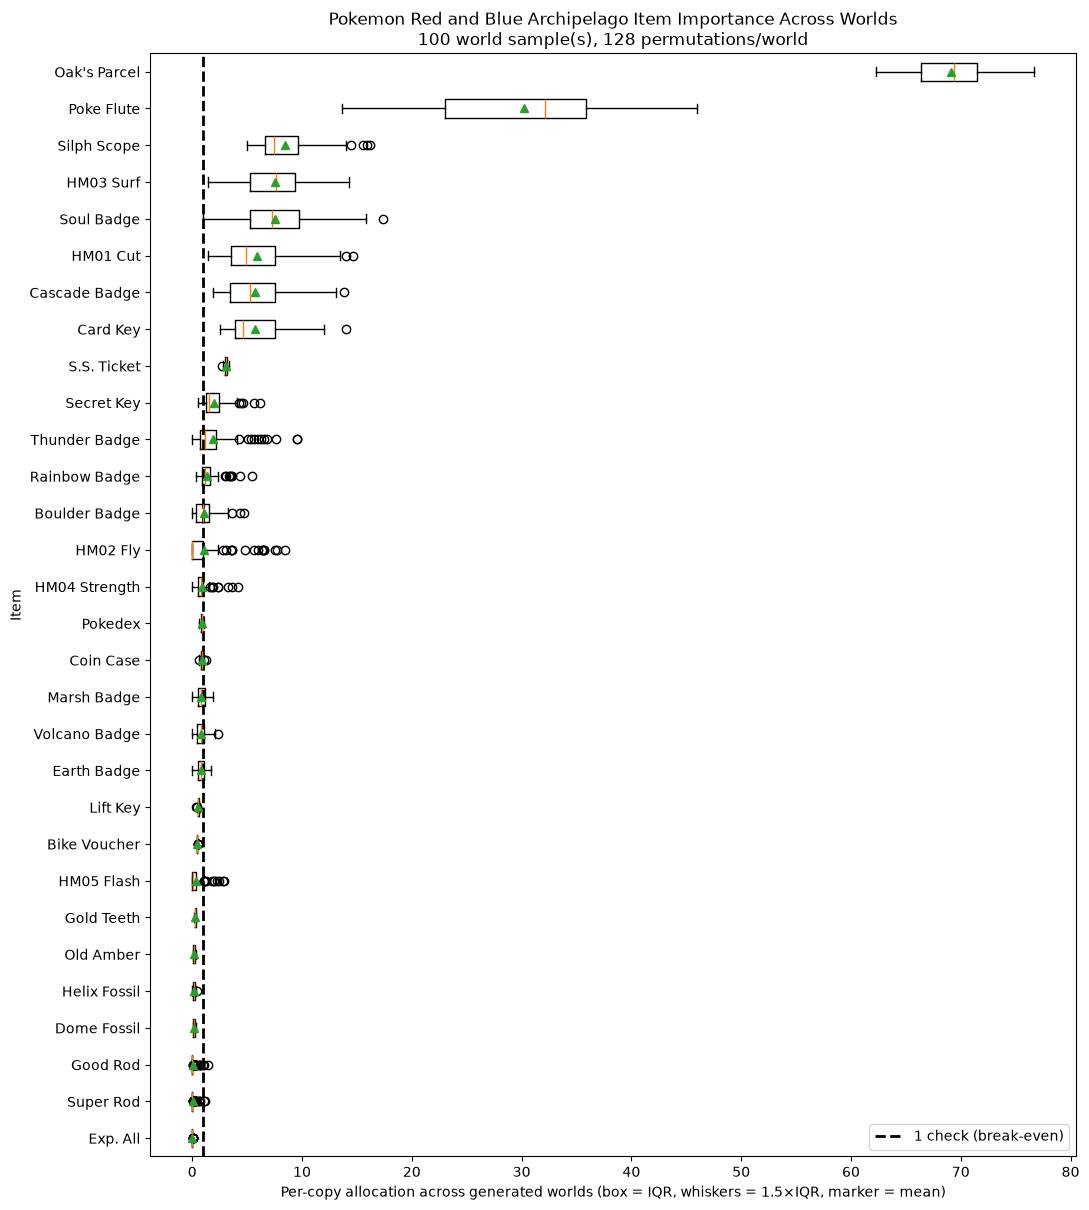

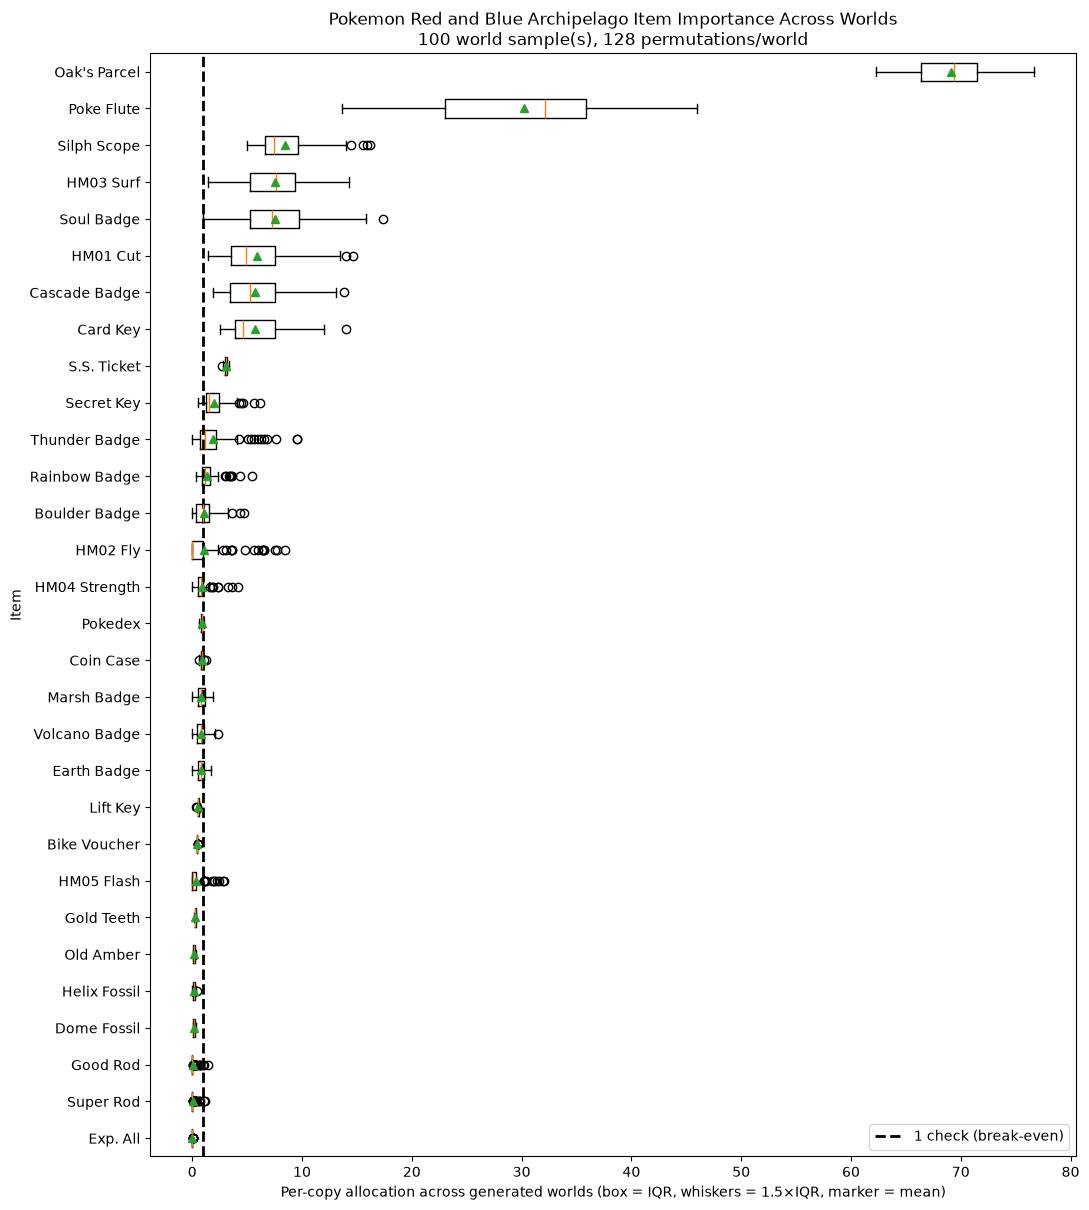

In [3]:
# Full distribution, including outlier worlds.
analysis.plot(top_n=30, show_outliers=True)  # plots shapley_per_copy

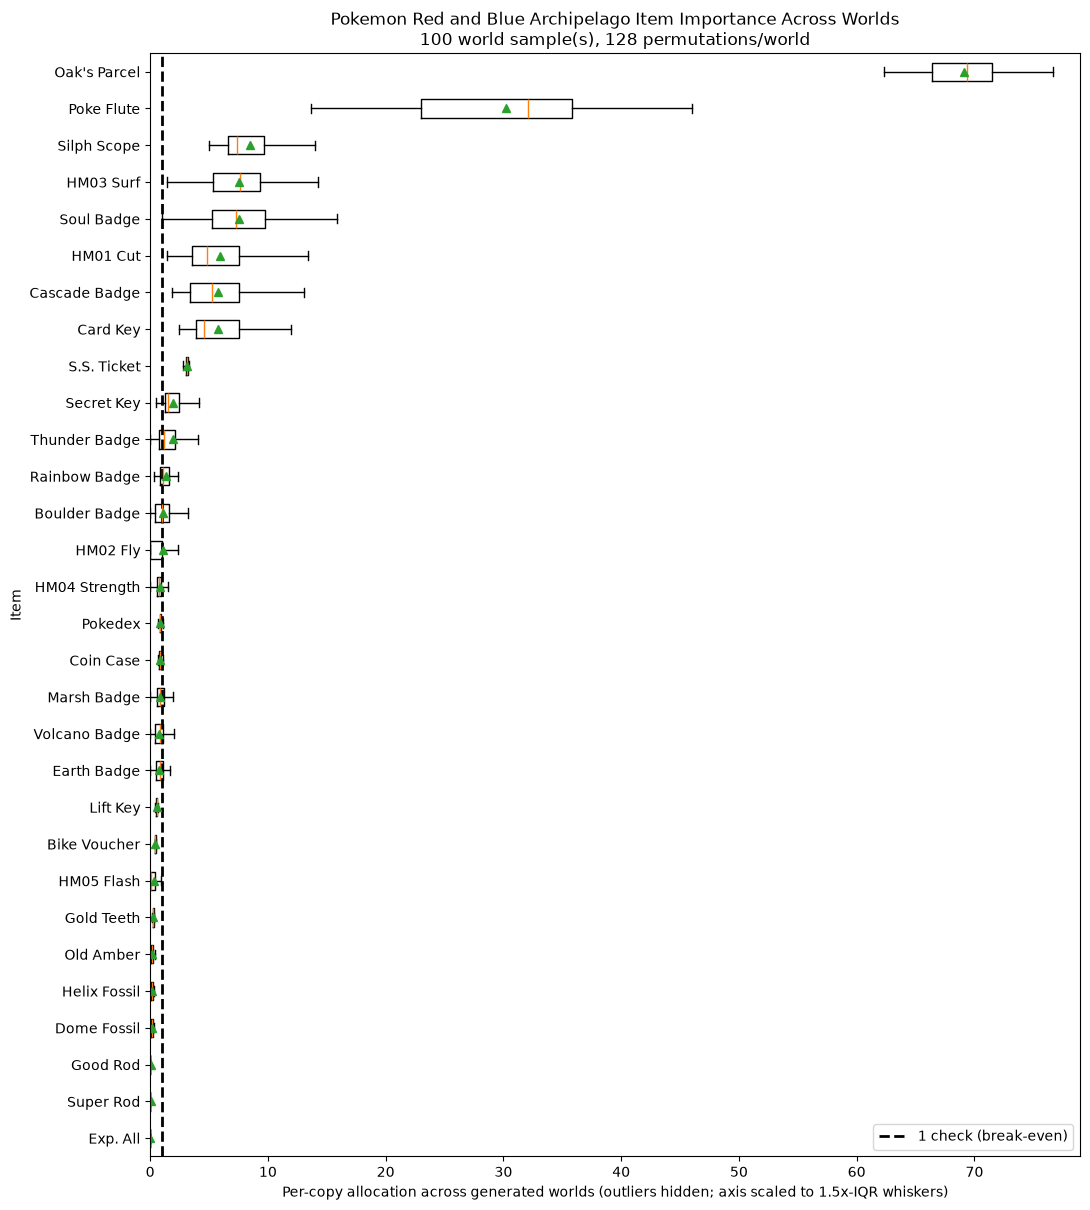

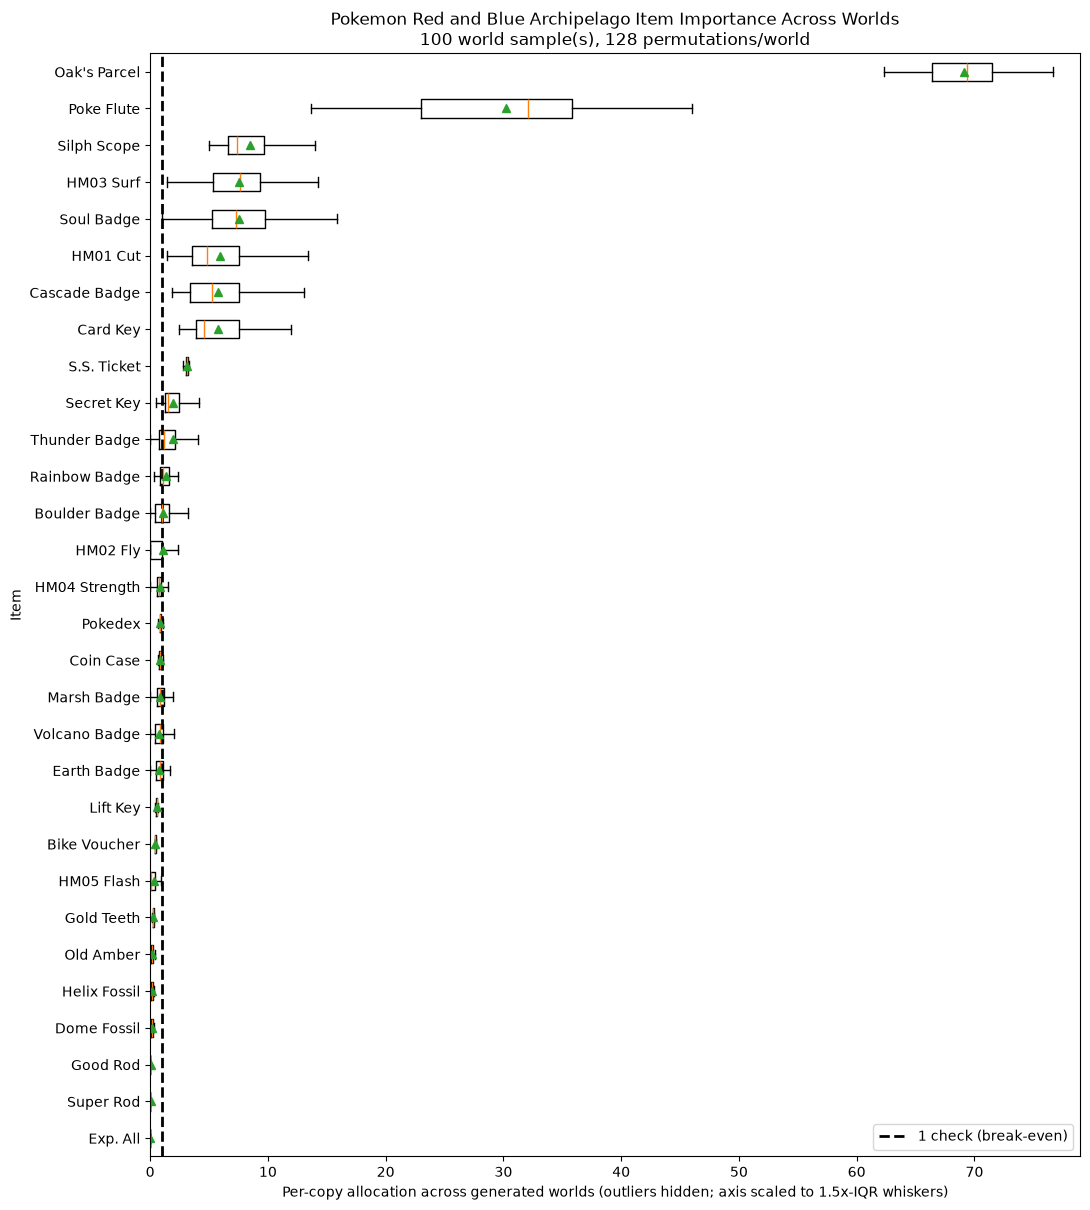

In [4]:
# Whisker-scaled view: same results and ranking, without outlier points stretching the axis.
analysis.plot(top_n=30, show_outliers=False)  # use metric='shapley_per_copy' to override

## Optional audit examples

Change the item or location names as desired.

In [5]:
# Replace this with any exact item name shown by display_items().
ITEM = "Silph Scope"
analysis.audit_item(ITEM, top_n=30)

=== Silph Scope ===
Worlds present: 100/100
Mean copies when present: 1.00
Per-copy Shapley value: 8.436 ± 0.509
Mean family total: 8.436
Sum of audited locations (per copy): 8.436


,location,per_copy_credit,approx_family_credit,approx_percent_of_check
0,Lavender Mr. Fuji's House - Mr. Fuji,0.343203,0.343203,34.320312
1,Silph Co 5F - Southwest Item,0.343203,0.343203,34.320312
2,Silph Co 7F - West Item,0.343203,0.343203,34.320312
3,Silph Co 10F - Right Item,0.343203,0.343203,34.320312
4,Silph Co 5F - Southeast Item,0.343203,0.343203,34.320312
5,Silph Co 10F - Left Item,0.343203,0.343203,34.320312
6,Silph Co 2F - Woman,0.343203,0.343203,34.320312
7,Silph Co 10F - Bottom Item,0.343203,0.343203,34.320312
8,Saffron Copycat's House 2F - Copycat,0.255312,0.255312,25.531250
9,Silph Co 4F - Right Item,0.255312,0.255312,25.531250


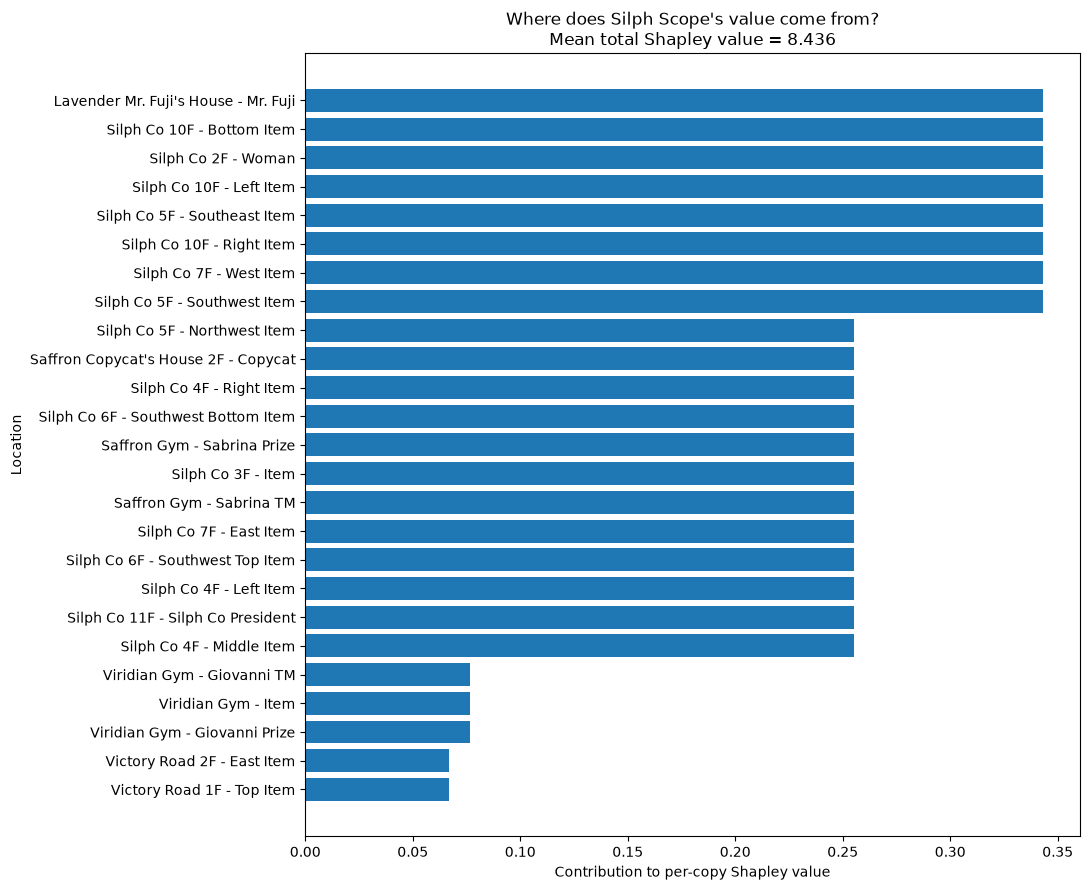

In [6]:
analysis.plot_audit(ITEM, top_n=25)